# Step 4 — Mean-Reversion Speed & Half-Life

In Step 3 we built a spread that *looks* mean-reverting. This step quantifies **how fast** it reverts.

This matters enormously for trading. Imagine two spreads that both eventually return to zero:
- Spread A reverts in **5 days** on average
- Spread B reverts in **300 days** on average

Spread A can generate dozens of trades per year. Spread B means your capital is tied up for almost a year per trade. Even if both are stationary in a strict mathematical sense, only Spread A is practically tradeable at daily frequency.

**The metric we use is the half-life** — the expected number of days for the spread to travel halfway back to its mean from any starting point.

**Sweet spot for daily pairs trading: 5 to 30 days.** Below 5 is too fast without high-frequency infrastructure. Above 30 days, capital efficiency suffers.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, str(Path.cwd().parent))

from pairs_trading.data import load_or_fetch
from pairs_trading.spread import estimate_hedge_ratio, build_spread, estimate_half_life, rolling_half_life

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def fmt_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.figure.autofmt_xdate(rotation=0, ha="center")

In [2]:
prices = load_or_fetch(["KO", "PEP"], "2018-01-01", "2025-01-01", name="ko_pep_7yr")
_, beta, _ = estimate_hedge_ratio(prices)
spread = build_spread(prices, beta)
print(f"Beta: {beta:.4f}  |  Spread length: {len(spread)} days")

Loading from cache: c:\Users\delosreyes.i\Downloads\Quant Claude Project\Pair-Regression-Testing\pairs_trading\data\ko_pep_7yr.parquet


Beta: 0.7972  |  Spread length: 1761 days


---
## The Ornstein-Uhlenbeck process

The **Ornstein-Uhlenbeck (OU) process** is the standard model for a mean-reverting series. Think of it like a spring: the further the spread is stretched from its equilibrium, the harder it gets pulled back.

The equation is:

> **dS = θ(μ − S) dt + σ dW**

| Symbol | Name | Plain meaning |
|---|---|---|
| θ (theta) | Mean-reversion speed | Strength of the pull back toward the mean. Larger = faster. |
| μ (mu) | Long-run mean | The equilibrium the spread returns to |
| σ dW | Random noise | Day-to-day unpredictable fluctuations |

---
## How we estimate θ from data

Discretised to daily steps, the OU equation becomes a simple **AR(1) regression**:

> **ΔSpread_t = coefficient × Spread_{t−1} + ε_t**

- **ΔSpread_t** = today's spread minus yesterday's (the daily change)
- **Spread_{t−1}** = yesterday's level
- The coefficient should be **negative** for mean-reversion: a high spread yesterday predicts a downward move today
- **θ = −coefficient**, then **half-life = ln(2) / θ**

In [3]:
half_life, theta, ar1_model = estimate_half_life(spread)

print("=" * 55)
print(f"  AR(1) coefficient     : {ar1_model.params['lag']:.6f}")
print(f"  theta                 : {theta:.6f}")
print(f"  Half-life             : {half_life:.1f} trading days")
print(f"  Half-life             : ~{half_life/21:.1f} months")
print("=" * 55)
print(f"  R-squared of AR(1)    : {ar1_model.rsquared:.4f}")
print(f"  p-value on theta      : {ar1_model.pvalues['lag']:.2e}")
print()
if half_life < 5:
    verdict = "Very fast - may be hard to execute."
elif half_life <= 30:
    verdict = "In the tradeable sweet spot (5-30 days). Good."
elif half_life <= 60:
    verdict = "Slow but workable. Lower capital efficiency."
else:
    verdict = "Very slow - strategy viability is questionable at daily frequency."
print(f"  Assessment: {verdict}")

  AR(1) coefficient     : -0.009631
  theta                 : 0.009631
  Half-life             : 72.0 trading days
  Half-life             : ~3.4 months
  R-squared of AR(1)    : 0.0042
  p-value on theta      : 6.32e-03

  Assessment: Very slow - strategy viability is questionable at daily frequency.


---
## Plot 1 — AR(1) regression: daily change vs yesterday's level

Each dot is one trading day.

- **X-axis**: yesterday's spread level (how far KO was from its fair value relative to PEP)
- **Y-axis**: today's change in spread (did it move toward or away from the mean?)

For mean reversion, the line must slope **downward**: when yesterday's spread was high (right side), today's change should be negative (pulling back). The steeper the slope, the faster the reversion, and the shorter the half-life.

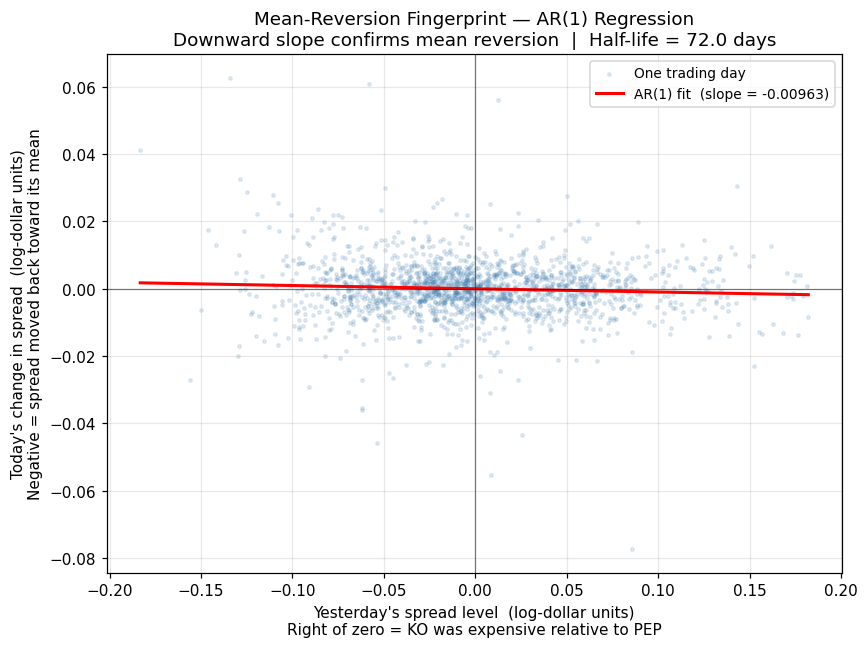

In [4]:
delta   = spread.diff().dropna()
lag     = spread.shift(1).dropna()
aligned = pd.concat([delta, lag], axis=1).dropna()
aligned.columns = ["delta", "lag"]

x_line = np.linspace(aligned["lag"].min(), aligned["lag"].max(), 200)
y_line = ar1_model.params["lag"] * x_line

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(aligned["lag"], aligned["delta"],
           alpha=0.15, s=5, color="steelblue", label="One trading day")
ax.plot(x_line, y_line, color="red", linewidth=2,
        label=f"AR(1) fit  (slope = {ar1_model.params['lag']:.5f})")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title(
    f"Mean-Reversion Fingerprint \u2014 AR(1) Regression\n"
    f"Downward slope confirms mean reversion  |  Half-life = {half_life:.1f} days"
)
ax.set_xlabel(
    "Yesterday's spread level  (log-dollar units)\n"
    "Right of zero = KO was expensive relative to PEP"
)
ax.set_ylabel(
    "Today's change in spread  (log-dollar units)\n"
    "Negative = spread moved back toward its mean"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Plot 2 — The theoretical decay curve vs the actual spread

The OU model predicts that a spread starting at distance S₀ from its mean decays toward zero as:

> **E[distance at time t] = S₀ × e^(−θ × t)**

The half-life is where this curve hits S₀/2.

The **left panel** shows the theoretical decay. The **right panel** shows the actual spread — noisier than the smooth curve (due to the random σ dW term), but the same underlying pull toward the mean.

**Practical read:** if you enter a trade at z = +2, the OU model says you expect to reach z = +1 after one half-life, and near z = 0 after roughly two half-lives. That's your expected holding period.

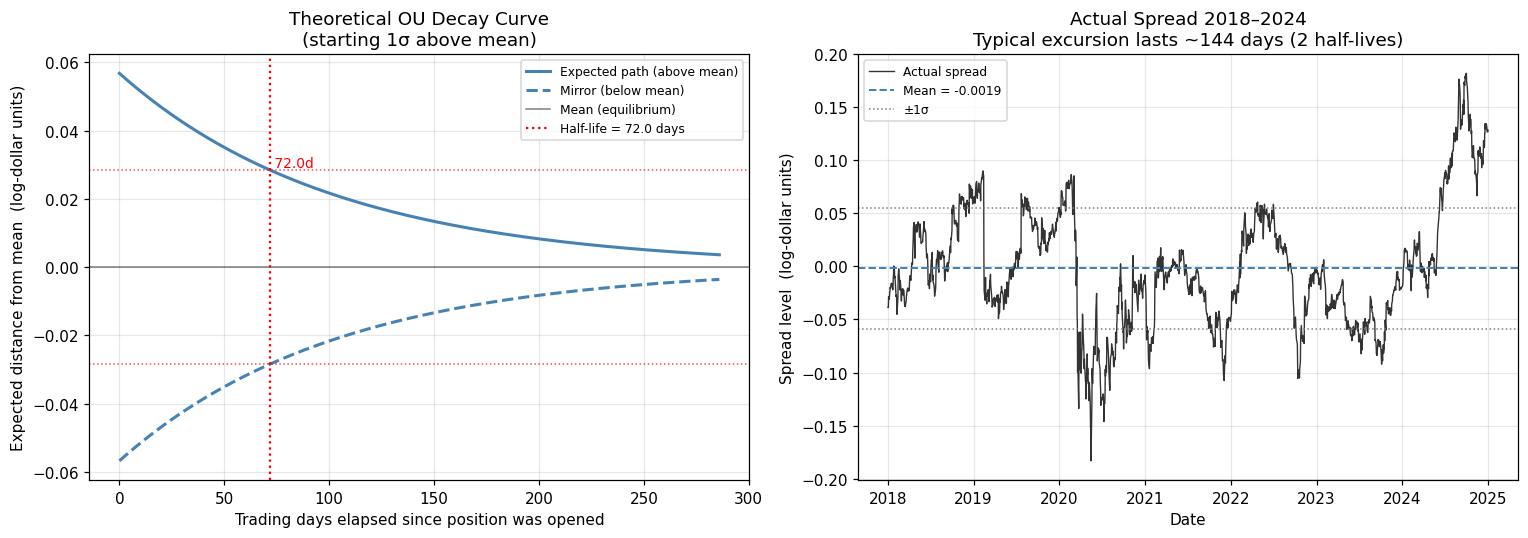

In [5]:
t     = np.arange(0, int(half_life * 4))
S0    = spread.std()
decay = S0 * np.exp(-theta * t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t,  decay,  color="steelblue", linewidth=2, label="Expected path (above mean)")
ax.plot(t, -decay,  color="steelblue", linewidth=2, linestyle="--", label="Mirror (below mean)")
ax.axhline(0,     color="black", linewidth=1, alpha=0.5, label="Mean (equilibrium)")
ax.axhline( S0/2, color="red",   linewidth=1, linestyle=":", alpha=0.7)
ax.axhline(-S0/2, color="red",   linewidth=1, linestyle=":", alpha=0.7)
ax.axvline(half_life, color="red", linewidth=1.5, linestyle=":",
           label=f"Half-life = {half_life:.1f} days")
ax.annotate(f" {half_life:.1f}d", xy=(half_life, S0/2), fontsize=9, color="red", va="bottom")
ax.set_title("Theoretical OU Decay Curve\n(starting 1\u03c3 above mean)")
ax.set_xlabel("Trading days elapsed since position was opened")
ax.set_ylabel("Expected distance from mean  (log-dollar units)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(spread.index, spread, color="black", linewidth=0.9, alpha=0.8, label="Actual spread")
ax.axhline(spread.mean(), color="steelblue", linestyle="--", linewidth=1.3,
           label=f"Mean = {spread.mean():.4f}")
ax.axhline(spread.mean() + spread.std(), color="gray", linestyle=":", linewidth=1, label="\u00b11\u03c3")
ax.axhline(spread.mean() - spread.std(), color="gray", linestyle=":", linewidth=1)
ax.set_title(f"Actual Spread 2018\u20132024\nTypical excursion lasts ~{half_life*2:.0f} days (2 half-lives)")
ax.set_xlabel("Date")
ax.set_ylabel("Spread level  (log-dollar units)")
ax.legend(fontsize=8)
fmt_dates(ax)

plt.tight_layout()
plt.show()

---
## Plot 3 — Rolling half-life: is mean reversion stable over time?

The full-sample half-life averages over 7 years. Mean-reversion speed changes — fast in some regimes, slow (or absent) in others.

We compute the half-life on a **rolling 252-day window** (one trading year). Each point answers: *"how long would a typical trade have taken to resolve, based on the past year?"*

**What to look for:**
- Does the line stay in the **green band (5–30 days)**? That's the sweet spot.
- **Spikes above 60–100 days**: periods where mean reversion nearly broke down — real losses would have occurred.
- **Stability overall**: a half-life that swings between 8 and 80 days is a riskier strategy than one that stays between 15 and 25.

Computing rolling half-life (252-day window) ...


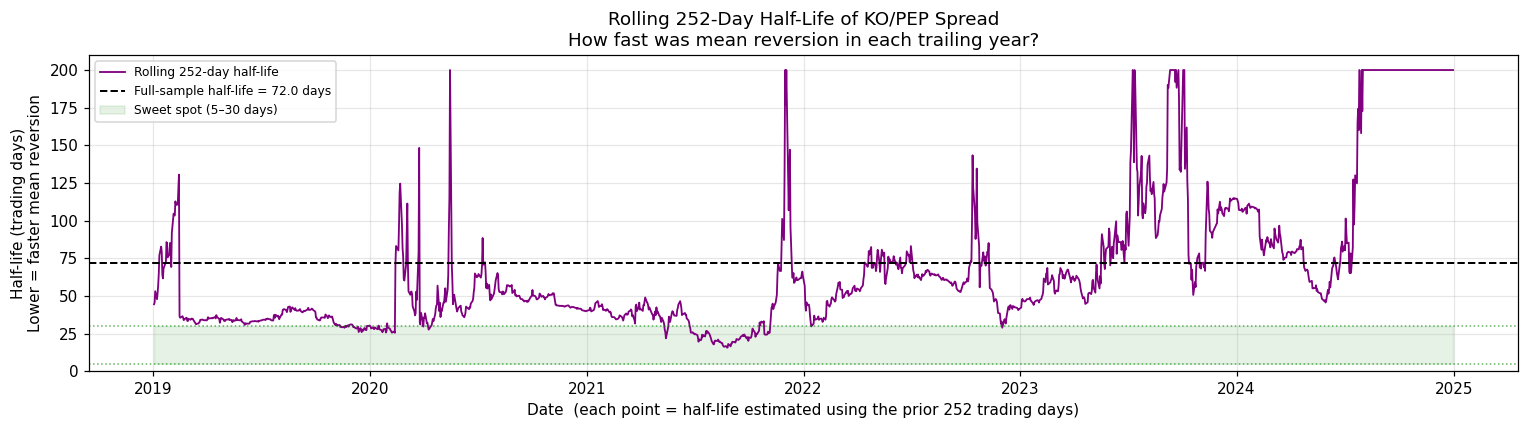

Rolling half-life  min : 15.7 days
                  mean : inf days
                   max : inf days (capped at 200 for display)
% of time in sweet spot (5-30 days): 10.1%


In [6]:
print("Computing rolling half-life (252-day window) ...")
roll_hl = rolling_half_life(spread, window=252)
roll_hl_capped = roll_hl.clip(upper=200)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_hl_capped.index, roll_hl_capped,
        color="purple", linewidth=1.2, label="Rolling 252-day half-life")
ax.axhline(half_life, color="black", linestyle="--", linewidth=1.3,
           label=f"Full-sample half-life = {half_life:.1f} days")
ax.fill_between(roll_hl_capped.index, 5, 30,
                color="green", alpha=0.10, label="Sweet spot (5\u201330 days)")
ax.axhline(5,  color="green", linestyle=":", linewidth=1, alpha=0.6)
ax.axhline(30, color="green", linestyle=":", linewidth=1, alpha=0.6)
ax.set_title(
    "Rolling 252-Day Half-Life of KO/PEP Spread\n"
    "How fast was mean reversion in each trailing year?"
)
ax.set_xlabel("Date  (each point = half-life estimated using the prior 252 trading days)")
ax.set_ylabel("Half-life (trading days)\nLower = faster mean reversion")
ax.legend(fontsize=8, loc="upper left")
ax.set_ylim(0, 210)
fmt_dates(ax)
plt.tight_layout()
plt.show()

pct_sweet = ((roll_hl >= 5) & (roll_hl <= 30)).mean() * 100
print(f"Rolling half-life  min : {roll_hl.min():.1f} days")
print(f"                  mean : {roll_hl.mean():.1f} days")
print(f"                   max : {roll_hl.max():.1f} days (capped at 200 for display)")
print(f"% of time in sweet spot (5-30 days): {pct_sweet:.1f}%")

---
## Summary

| Result | Value | What it means |
|---|---|---|
| θ (theta) | see cell output | The spring constant — strength of the mean-reversion pull |
| Full-sample half-life | see cell output | Expected days to travel halfway back to mean |
| AR(1) p-value | very small | Mean reversion is statistically real, not a fluke |
| Rolling half-life | see chart | Whether reversion speed is stable or regime-dependent |

### What this means for trade design (preview of Steps 7 & 8)

The half-life directly informs three later decisions:

1. **Expected holding period per trade**: roughly 2 × half-life days (one half-life to go from 2σ to 1σ, another to reach ~0)
2. **Stop-loss timing**: if a trade hasn't resolved after 3–4× the half-life, something may have broken — exit
3. **Walk-forward training window**: should cover at least 5–10 half-life cycles; for a ~20-day half-life, a 252-day window is appropriate

---
### Caveat

The AR(1) regression fits a mean-reversion model even on a random walk — it just won't be statistically significant. The p-value on θ is encouraging, but the formal proof comes in **Step 5 (cointegration testing)** with the Engle-Granger and Johansen tests.